✅ PhysNet loaded
📋 Evaluating 12 validation subjects: ['09-02', '02-05', '04-05', '04-01', '10-06', '04-03', '02-02', '08-04', '03-03', '05-05', '10-01', '07-04']
  09-02 | True: 49.43 | Pred: 49.39 | Err: 0.04
  02-05 | True: 73.82 | Pred: 73.84 | Err: 0.01
  04-05 | True: 59.82 | Pred: 59.88 | Err: 0.07
  04-01 | True: 56.25 | Pred: 56.31 | Err: 0.06
  10-06 | True: 77.34 | Pred: 77.29 | Err: 0.05
  04-03 | True: 67.56 | Pred: 67.28 | Err: 0.29
  02-02 | True: 81.70 | Pred: 82.45 | Err: 0.75
  08-04 | True: 52.53 | Pred: 52.63 | Err: 0.10
  03-03 | True: 59.78 | Pred: 59.00 | Err: 0.78
  05-05 | True: 49.17 | Pred: 49.19 | Err: 0.02
  10-01 | True: 81.10 | Pred: 81.36 | Err: 0.26
  07-04 | True: 117.44 | Pred: 118.72 | Err: 1.28

📊 MAE: 0.31 BPM | R²: 0.9993


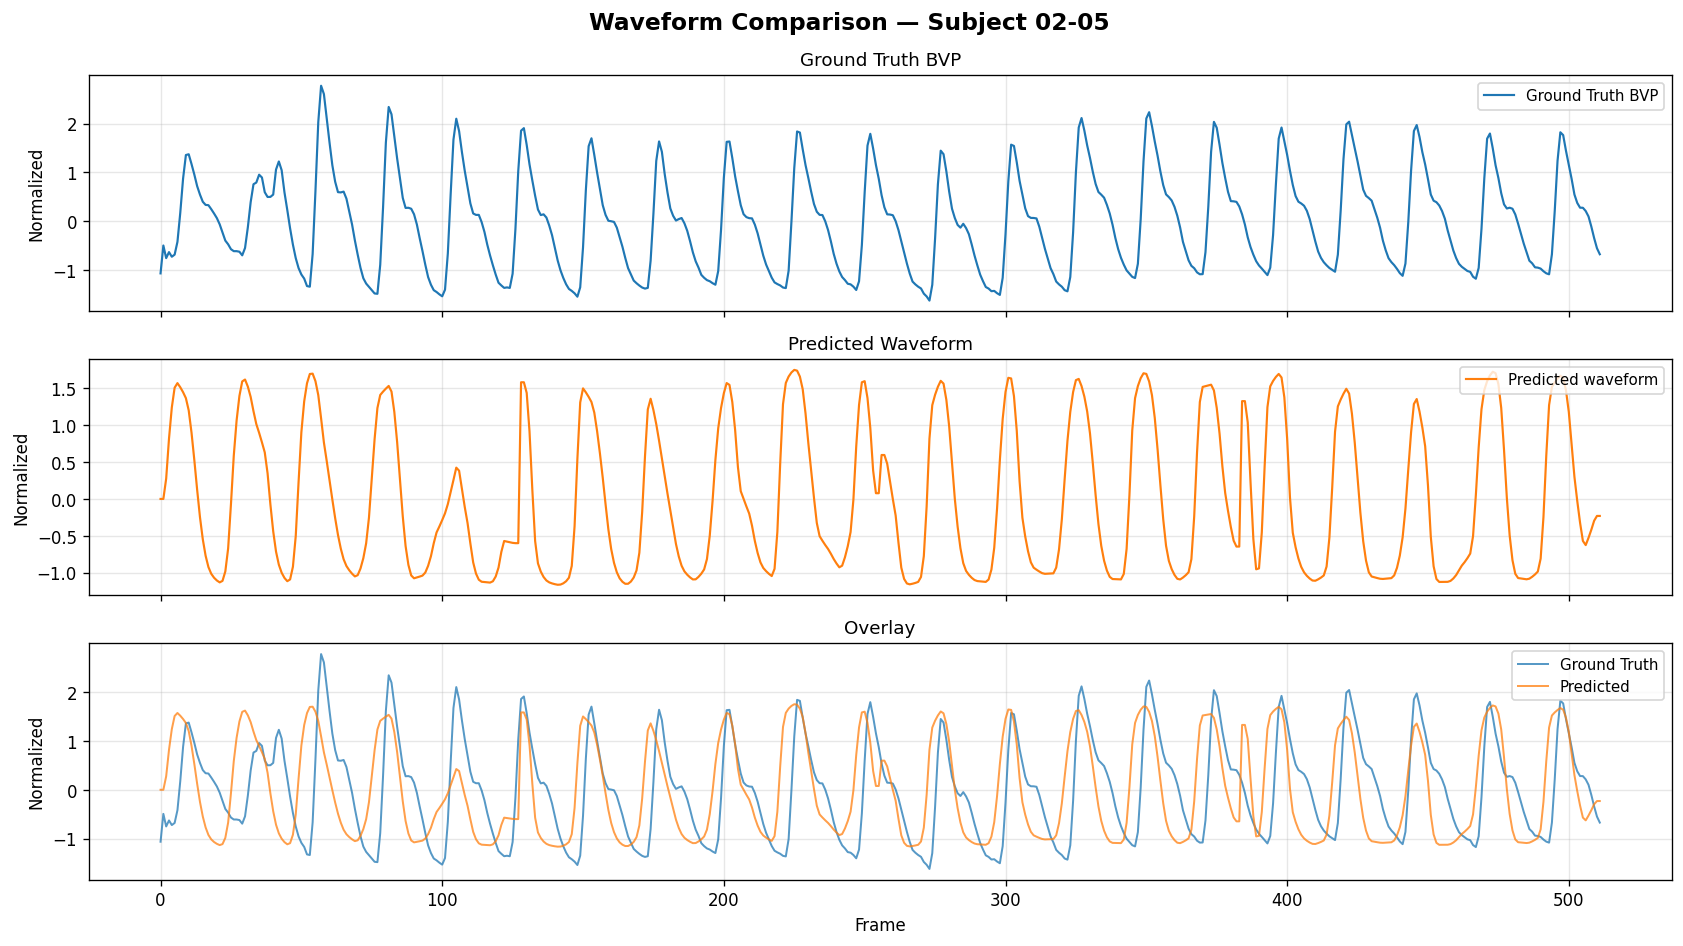

💾 Saved: /home/imji/rPPG/evaluation/waveform_comparison.png


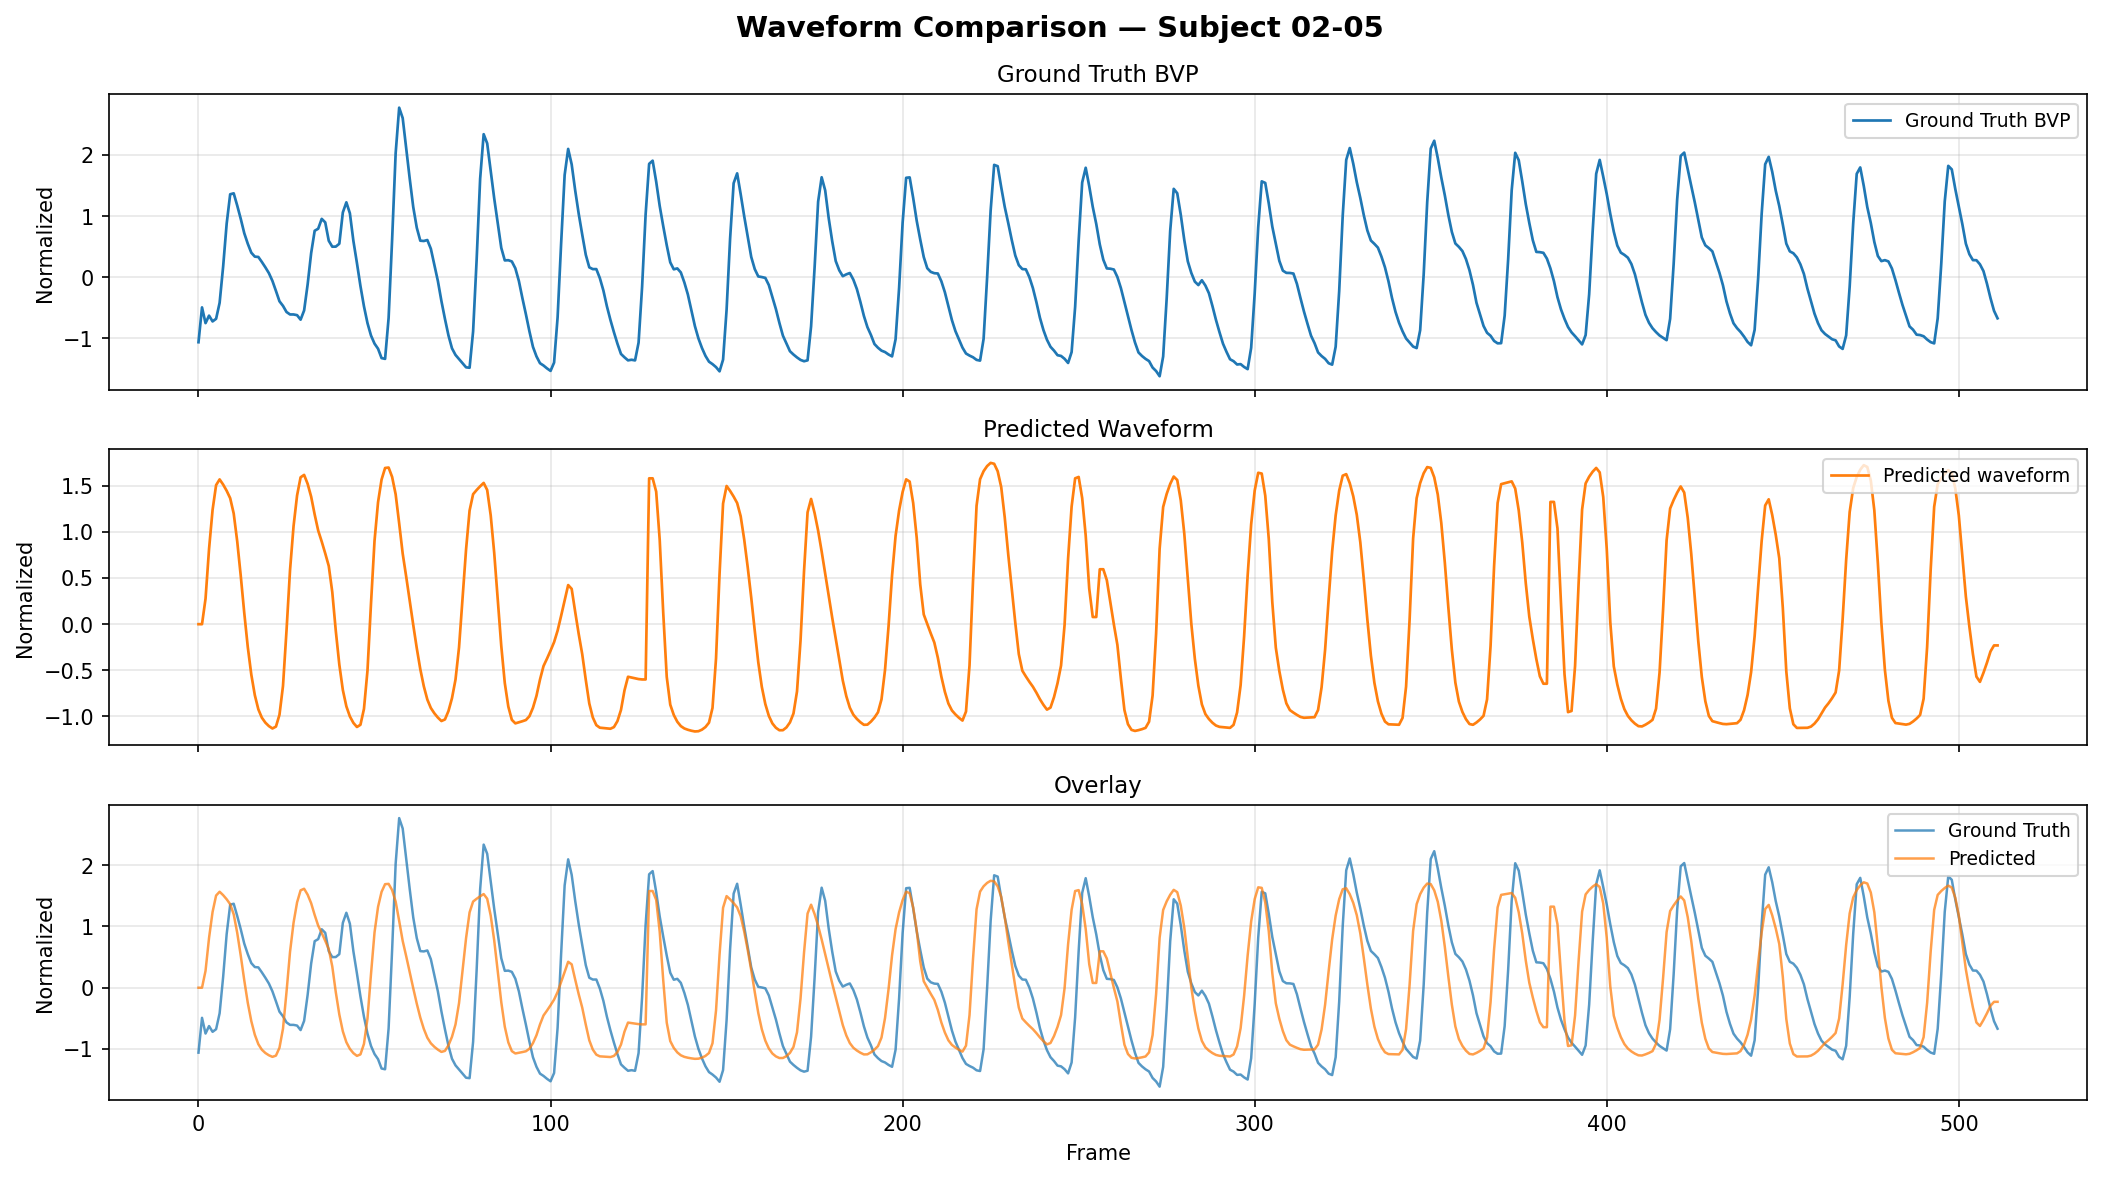

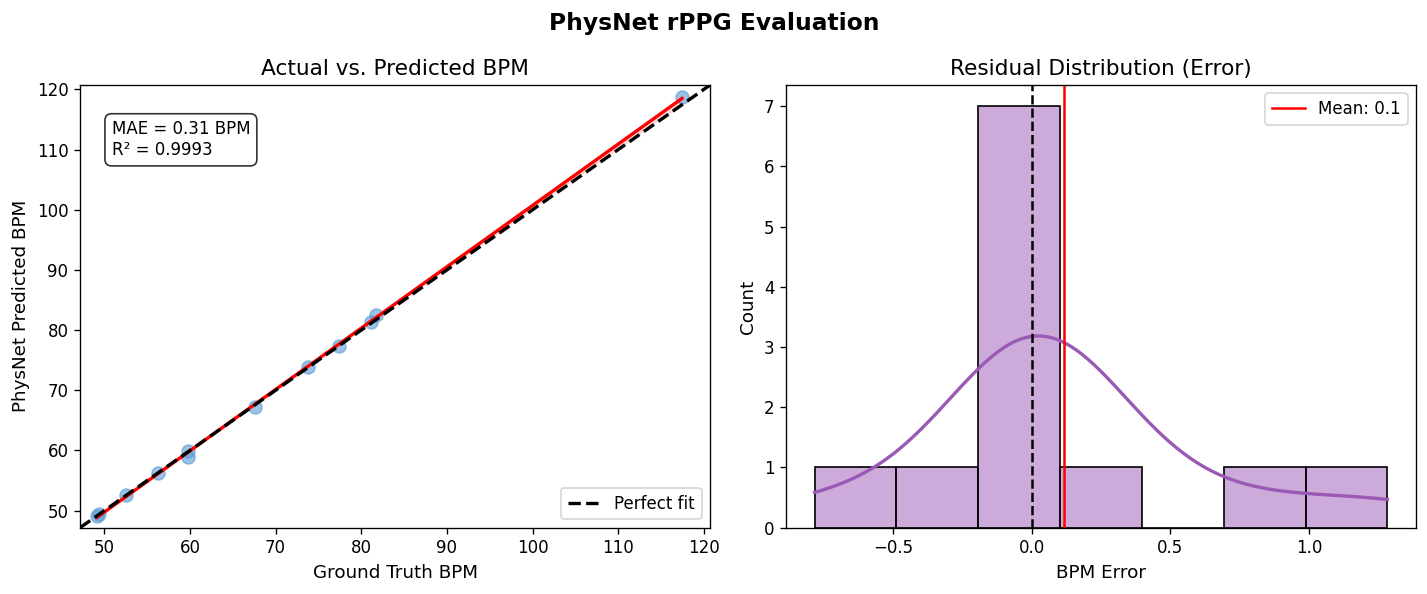

💾 Saved: /home/imji/rPPG/evaluation/evaluation_results.png


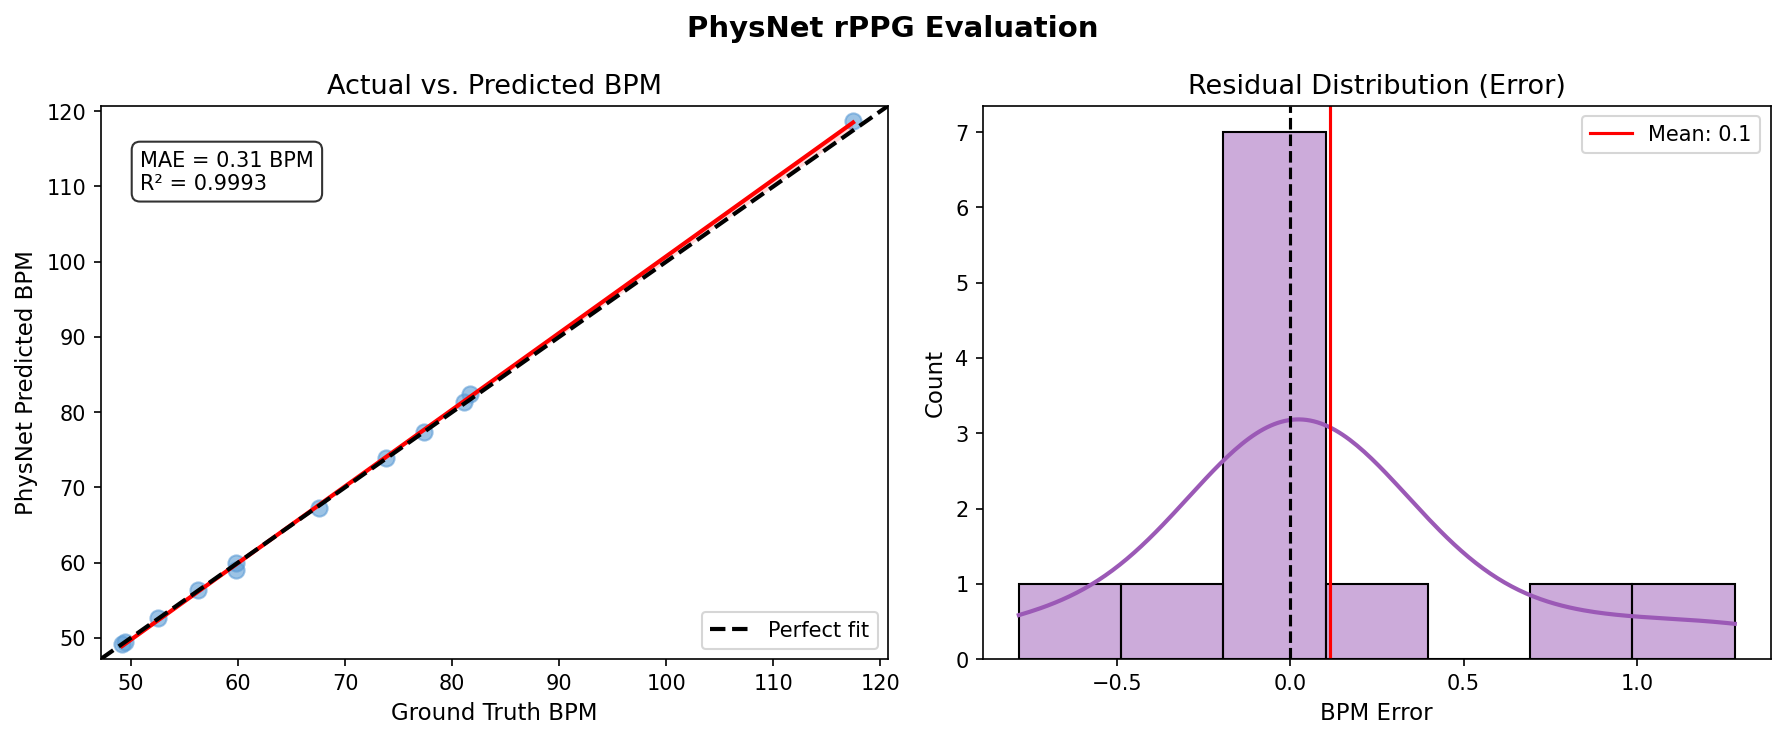


  EVALUATION SUMMARY
  Subjects evaluated : 12
  MAE                : 0.31 BPM
  R²                 : 0.9993
  Bias               : 0.11 BPM
  Std of errors      : 0.49 BPM
  Max error          : 1.28 BPM
  Waveform saved     : /home/imji/rPPG/evaluation/waveform_comparison.png
  Eval plot saved    : /home/imji/rPPG/evaluation/evaluation_results.png
⚠️  Results look strong — verify with more subjects


In [13]:
# ============================================================
# PhysNet rPPG — Full Evaluation Notebook Cell
# Produces:
#   1. Waveform comparison plot (3-panel)
#   2. BPM evaluation plot (scatter + residuals)
# Saves both as PNG files.
# ============================================================

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['figure.dpi'] = 120

import sys
import os
import torch
import torch.nn.functional as F
import numpy as np
import h5py
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import Image, display

# --- Path setup ---
sys.path.append("/home/imji/rPPG")
from models import PhysNet

# --- Config ---
MODEL_PATH   = "/home/imji/rPPG/models/best_model.pth"
H5_PATH      = "/home/imji/rPPG/models/pure_processed_192.h5"
WAVE_SUBJECT = "02-05"       # subject to use for waveform plot
SAVE_DIR     = "/home/imji/rPPG/evaluation"
FPS          = 30
T            = 128
SPATIAL      = 64
T_EVAL       = 512           # longer window for better BPM resolution

os.makedirs(SAVE_DIR, exist_ok=True)

# ==============================================================
# 1. Load model
# ==============================================================
model = PhysNet(T=T)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu", weights_only=True))
model.eval()
print("✅ PhysNet loaded")

# ==============================================================
# 2. Val subjects (same seed as training)
# ==============================================================
with h5py.File(H5_PATH, 'r') as f:
    all_subs = list(f.keys())

np.random.seed(42)
np.random.shuffle(all_subs)
val_subs = all_subs[int(len(all_subs) * 0.8):]
print(f"📋 Evaluating {len(val_subs)} validation subjects: {val_subs}")

# ==============================================================
# 3. Helper functions
# ==============================================================
def run_inference_chunks(frames, window=128, spatial=64):
    """Run model on long clip by splitting into chunks."""
    pred_chunks = []
    for start in range(0, len(frames), window):
        chunk = frames[start:start + window]
        if len(chunk) < window:
            break
        video = torch.from_numpy(
            np.transpose(chunk.astype(np.float32) / 255.0, (3, 0, 1, 2))
        ).unsqueeze(0)
        video = F.interpolate(video, size=(window, spatial, spatial),
                              mode='trilinear', align_corners=False)
        with torch.no_grad():
            out = model(video).squeeze().numpy()
        pred_chunks.append(out)
    return np.concatenate(pred_chunks)


def waveform_to_bpm(waveform, fps=30):
    """FFT-based BPM with parabolic interpolation for sub-bin accuracy."""
    N      = len(waveform)
    signal = waveform - waveform.mean()
    power  = np.abs(np.fft.rfft(signal)) ** 2
    freqs  = np.fft.rfftfreq(N, d=1.0 / fps)
    valid  = (freqs >= 0.67) & (freqs <= 3.0)
    if not valid.any():
        return 0.0
    valid_freqs = freqs[valid]
    valid_power = power[valid]
    peak_idx    = np.argmax(valid_power)
    if 0 < peak_idx < len(valid_power) - 1:
        alpha      = valid_power[peak_idx - 1]
        beta       = valid_power[peak_idx]
        gamma      = valid_power[peak_idx + 1]
        correction = 0.5 * (alpha - gamma) / (alpha - 2*beta + gamma + 1e-8)
        bin_width  = valid_freqs[1] - valid_freqs[0]
        peak_freq  = valid_freqs[peak_idx] + correction * bin_width
    else:
        peak_freq = valid_freqs[peak_idx]
    return float(peak_freq * 60.0)


def normalize(sig):
    std = sig.std()
    return (sig - sig.mean()) / (std + 1e-8) if std > 1e-6 else np.zeros_like(sig)


# ==============================================================
# 4. Run inference on all val subjects
# ==============================================================
y_pred, y_true = [], []

with h5py.File(H5_PATH, 'r') as f:
    for sub in val_subs:
        total = f[sub]['frames'].shape[0]
        if total < T_EVAL:
            print(f"  ⚠️  {sub}: only {total} frames, skipping")
            continue
        frames   = f[sub]['frames'][:T_EVAL]
        bvp      = f[sub]['bvp'][:T_EVAL]
        pred_wave = run_inference_chunks(frames, T, SPATIAL)
        pred_bpm  = waveform_to_bpm(pred_wave, FPS)
        true_bpm  = waveform_to_bpm(bvp,       FPS)
        y_pred.append(pred_bpm)
        y_true.append(true_bpm)
        print(f"  {sub} | True: {true_bpm:.2f} | Pred: {pred_bpm:.2f} | Err: {abs(pred_bpm-true_bpm):.2f}")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
mae    = mean_absolute_error(y_true, y_pred)
r2     = r2_score(y_true, y_pred)
print(f"\n📊 MAE: {mae:.2f} BPM | R²: {r2:.4f}")

# ==============================================================
# FIGURE 1 — Waveform Comparison
# ==============================================================
with h5py.File(H5_PATH, 'r') as f:
    wave_frames = f[WAVE_SUBJECT]['frames'][:T_EVAL]
    wave_bvp    = f[WAVE_SUBJECT]['bvp'][:T_EVAL]

pred_wave_full = run_inference_chunks(wave_frames, T, SPATIAL)
bvp_norm  = normalize(wave_bvp.astype(np.float32))
pred_norm = normalize(pred_wave_full)

fig1, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig1.suptitle(f"Waveform Comparison — Subject {WAVE_SUBJECT}", fontsize=14, fontweight='bold')

axes[0].plot(bvp_norm,  color='#1f77b4', linewidth=1.3, label='Ground Truth BVP')
axes[0].set_title("Ground Truth BVP", fontsize=11)
axes[0].set_ylabel("Normalized")
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(pred_norm, color='#ff7f0e', linewidth=1.3, label='Predicted waveform')
axes[1].set_title("Predicted Waveform", fontsize=11)
axes[1].set_ylabel("Normalized")
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(bvp_norm,  color='#1f77b4', linewidth=1.2, alpha=0.75, label='Ground Truth')
axes[2].plot(pred_norm, color='#ff7f0e', linewidth=1.2, alpha=0.75, label='Predicted')
axes[2].set_title("Overlay", fontsize=11)
axes[2].set_ylabel("Normalized")
axes[2].set_xlabel("Frame", fontsize=10)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
wave_path = os.path.join(SAVE_DIR, "waveform_comparison.png")
fig1.savefig(wave_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {wave_path}")
display(Image(wave_path))

# ==============================================================
# FIGURE 2 — BPM Evaluation (Scatter + Residuals)
# ==============================================================
residuals = y_pred - y_true

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("PhysNet rPPG Evaluation", fontsize=14, fontweight='bold')

# --- Left: Actual vs Predicted ---
ax1 = axes2[0]
sns.regplot(x=y_true, y=y_pred, ax=ax1,
            scatter_kws={'alpha': 0.6, 's': 60, 'color': '#5b9bd5'},
            line_kws={'color': 'red', 'linewidth': 2}, ci=95)
lims = [min(y_true.min(), y_pred.min()) - 2,
        max(y_true.max(), y_pred.max()) + 2]
ax1.plot(lims, lims, 'k--', linewidth=2, label='Perfect fit')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_title("Actual vs. Predicted BPM", fontsize=13)
ax1.set_xlabel("Ground Truth BPM", fontsize=11)
ax1.set_ylabel("PhysNet Predicted BPM", fontsize=11)
ax1.legend(fontsize=10)
ax1.annotate(
    f"MAE = {mae:.2f} BPM\nR² = {r2:.4f}",
    xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8)
)

# --- Right: Residual Distribution ---
ax2 = axes2[1]
sns.histplot(residuals, kde=True, color='#9b59b6', ax=ax2,
             line_kws={'linewidth': 2})
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.axvline(residuals.mean(), color='red', linestyle='-',
            linewidth=1.5, label=f'Mean: {residuals.mean():.1f}')
ax2.set_title("Residual Distribution (Error)", fontsize=13)
ax2.set_xlabel("BPM Error", fontsize=11)
ax2.set_ylabel("Count", fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
eval_path = os.path.join(SAVE_DIR, "evaluation_results.png")
fig2.savefig(eval_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved: {eval_path}")
display(Image(eval_path))

# ==============================================================
# Summary
# ==============================================================
print("\n" + "="*45)
print("  EVALUATION SUMMARY")
print("="*45)
print(f"  Subjects evaluated : {len(y_true)}")
print(f"  MAE                : {mae:.2f} BPM")
print(f"  R²                 : {r2:.4f}")
print(f"  Bias               : {residuals.mean():.2f} BPM")
print(f"  Std of errors      : {residuals.std():.2f} BPM")
print(f"  Max error          : {np.abs(residuals).max():.2f} BPM")
print(f"  Waveform saved     : {wave_path}")
print(f"  Eval plot saved    : {eval_path}")
print("="*45)
if r2 < 0.1:
    print("🚩 UNDERFITTING")
elif r2 > 0.95 and mae < 1.0:
    print("⚠️  Results look strong — verify with more subjects")
else:
    print("✅ NORMAL — model shows correlation with ground truth")